# Lab 2 Ghofran's code

In [14]:

#####################################
### Import the relevant libraries ###
#####################################
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


In [2]:
####################################
##### Load the cleaned dataset #####
####################################
DATA_PATH = "cleaned_medicheck-expert.csv"  
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print(df.head(3))

Shape: (1416, 2)
                                               query  query-label-expert
0  Why do i get a bad headache when i don't eat e...                   2
1  What causes heart rate to suddenly quicken to ...                   2
2  peritonsillar abscess drainage aftercare.. ple...                   2


In [ ]:
##########################################
# Relabel to binary according to ANTONIO #
##########################################  
def antonio_relabel(x):
    if x in [1, 2, 3]:   # any medical seriousness level
        return 0         # medical
    elif x == 0:
        return 1         # non-medical
    else:
        return np.nan

df = df[["query", "query-label-expert"]].copy()
df["label"] = df["query-label-expert"].apply(antonio_relabel)
df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)
df["query"] = df["query"].astype(str).str.replace(r"\s+"," ", regex=True).str.strip()

print("Label distribution (ANTONIO):\n", df["label"].value_counts())
df.head(5)

Label distribution (ANTONIO):
 label
0    1412
1       4
Name: count, dtype: int64


,query,query-label-expert,label
0,Why do i get a bad headache when i don't eat e...,2,0
1,What causes heart rate to suddenly quicken to ...,2,0
2,peritonsillar abscess drainage aftercare.. ple...,2,0
3,How serious is Mono or tonsillitis when untrea...,2,0
4,What are your chances of dying in your sleep?,1,0


In [5]:
# Step 3D — Show a few examples from each class
print("\nMedical (label 0) examples:")
print(df[df.label==0].sample(min(3, (df.label==0).sum()), random_state=SEED)["query"].tolist())

print("\nNon-medical (label 1) examples:")
print(df[df.label==1].sample(min(3, (df.label==1).sum()), random_state=SEED)["query"].tolist())


Medical (label 0) examples:
['How do I find a Therapist?', 'Why do my eyes get super red when I smoke marijuana?', 'Feeling I might faint at any moment, dizzyness, lightheadedness']

Non-medical (label 1) examples:
['Writer with a question: What kind of medical situations do you have to inform the police about?', 'How to responsibly take advantage of maxed deductible?', 'If humans were not restrained by the obstetrical dilemma, how many weeks, on average, would a fetus take to naturally gestate inside the womb before birth, and and how large would it get?']


In [ ]:
############################################
###### Split data into train and test ######
############################################
X = df["query"].values
y = df["label"].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=SEED, stratify=y)

print("Train size:", len(X_train_text), " Test size:", len(X_test_text))
print("Train label counts:", np.bincount(y_train))
print("Test  label counts:", np.bincount(y_test))

Train size: 991  Test size: 425
Train label counts: [988   3]
Test  label counts: [424   1]


In [7]:
######################################################################
# Turn text into numerical features >> Vectorizing the text (TF-IDF) #
######################################################################
# Step 3F — Vectorization (TF-IDF -> dense -> scaled to [0,1] for stable PGD)
vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf  = vectorizer.transform(X_test_text)

# convert to dense arrays for Keras + PGD
X_train_dense = X_train_tfidf.toarray().astype("float32")
X_test_dense  = X_test_tfidf.toarray().astype("float32")

# scale each feature to [0,1] (helps PGD step sizes)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_dense).astype("float32")
X_test  = scaler.transform(X_test_dense).astype("float32")

X_train.shape, X_test.shape

((991, 5000), (425, 5000))

In [8]:
#############################
# Define and train NN model #
#############################
# Step 3G — Define a small dense NN
def build_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

model = build_model(X_train.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,296,769 (4.95 MB)

 Trainable params: 1,296,769 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

Class weights: {0: 0.5015182186234818, 1: 165.16666666666666}
Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.9495 - loss: 0.8316 - val_accuracy: 1.0000 - val_loss: 0.2945
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9966 - loss: 0.7513 - val_accuracy: 1.0000 - val_loss: 0.1423
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9966 - loss: 0.5067 - val_accuracy: 1.0000 - val_loss: 0.0880
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9978 - loss: 0.4214 - val_accuracy: 1.0000 - val_loss: 0.0595
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 1.0000 - loss: 0.3328 - val_accuracy: 1.0000 - val_loss: 0.0425
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 1.0000 - loss: 0.2760 - val_accuracy: 1.0000 - val_loss: 0.0329
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 1.0000 - loss: 0.2169 - val_accuracy: 1.0000 - val_loss: 0.0271
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/ste

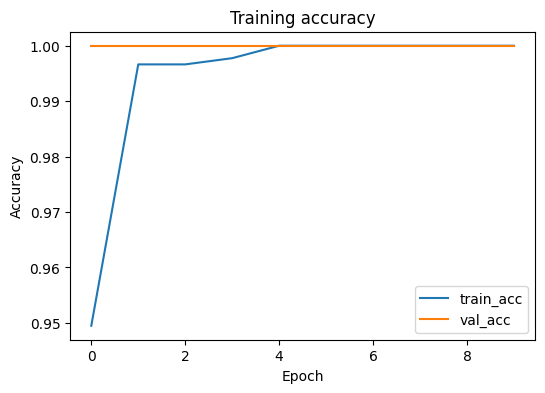

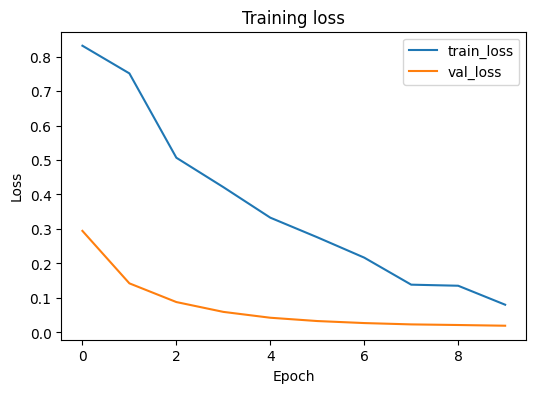

In [10]:
# Optional: compute class weights (helps if non-medical is rare)
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
print("Class weights:", class_weight_dict)

# Step 3G (cont.) — Train baseline
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1,
    class_weight=class_weight_dict  # remove this arg if you don't want weighting
)

# Plot training curves
plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Training accuracy"); plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("Training loss"); plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Clean accuracy: 0.9976470588235294

Classification report:
               precision    recall  f1-score   support

           0      0.998     1.000     0.999       424
           1      0.000     0.000     0.000         1

    accuracy                          0.998       425
   macro avg      0.499     0.500     0.499       425
weighted avg      0.995     0.998     0.996       425



c:\Users\ghofr\Documents\GitHub\CDT-D2AIR-NLP\tfenv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ghofr\Documents\GitHub\CDT-D2AIR-NLP\tfenv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ghofr\Documents\GitHub\CDT-D2AIR-NLP\tfenv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

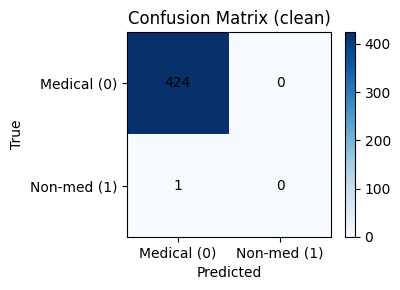

In [11]:
# Step 3H — Evaluation on clean test set
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("Clean accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (clean)")
plt.colorbar()
plt.xticks([0,1], ["Medical (0)", "Non-med (1)"])
plt.yticks([0,1], ["Medical (0)", "Non-med (1)"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()


In [13]:
# Step 3I — Feature entanglement: hidden activations -> PCA 2D
# model up to the 64-unit layer
feature_extractor = keras.Model(inputs=model.input, outputs=model.layers[-2].output)

# use a subset if data is large
X_all = np.vstack([X_train[:2000], X_test[:2000]])
y_all = np.concatenate([y_train[:2000], y_test[:2000]])

H = feature_extractor.predict(X_all, batch_size=256)
pca = PCA(n_components=2, random_state=SEED)
H2 = pca.fit_transform(H)

plt.figure(figsize=(6,5))
scatter = plt.scatter(H2[:,0], H2[:,1], c=y_all, alpha=0.6)
plt.title("Feature entanglement (PCA of hidden activations)")
plt.xlabel("PC1"); plt.ylabel("PC2")
cbar = plt.colorbar(scatter, ticks=[0,1]); cbar.ax.set_yticklabels(["Medical (0)","Non-med (1)"])
plt.tight_layout(); plt.show()


AttributeError: The layer sequential has never been called and thus has no defined input.